# M3: Stock–Watson soft factor and the short-window horse race

The short-window soft block has five monthly indicators (UMCSENT, EPU,
and the NY / Philadelphia / Dallas Fed manufacturing surveys). Rather
than dump all five into a VAR on ~80 observations, we extract their
first principal component (Stock–Watson) and add that single factor to
the hard block.

All forecast results use the **COVID-dummy VAR** from M2, so COVID is
modeled, not dropped. Inputs are loaded from disk (cached pickle +
parquet); no FRED calls.

Contents:
1. Factor diagnostics — loading stability across recursive refits.
2. Factor history with recession bands.
3. Short-window horse race: hard vs hard+UMCSENT vs hard+soft-factor.
4. Giacomini–White test.
5. Takeaways.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load_config import load_config
from evaluation.feature_frame import build_feature_frame
from evaluation.harness import monthly_origins
from evaluation.gw import gw_test
from models.soft_factor import SoftFactor

ROOT = Path.cwd().parent
cfg = load_config(str(ROOT / 'configs/us.yaml'), secrets_path=str(ROOT / 'config.yaml'))
with open(ROOT / 'data/cache/inputs.pkl', 'rb') as f:
    d = pickle.load(f)
cubes, static = d['cubes'], d['static']

vix_m = static['VIXCLS'].copy(); vix_m.index = pd.to_datetime(vix_m.index)
vix_m = vix_m.resample('MS').mean()

BANDS = [(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01')),
         (pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'))]

SOFT = ['consumer_sentiment','epu','empire_state_mfg','philly_fed_mfg','dallas_fed_mfg']
ORIGINS = monthly_origins('2018-01-01','2024-12-01')

## 1. Loading stability across recursive refits

At each origin the factor is refit on only the data available then. If
it is well-behaved, the loadings shouldn't lurch around as one month is
added.

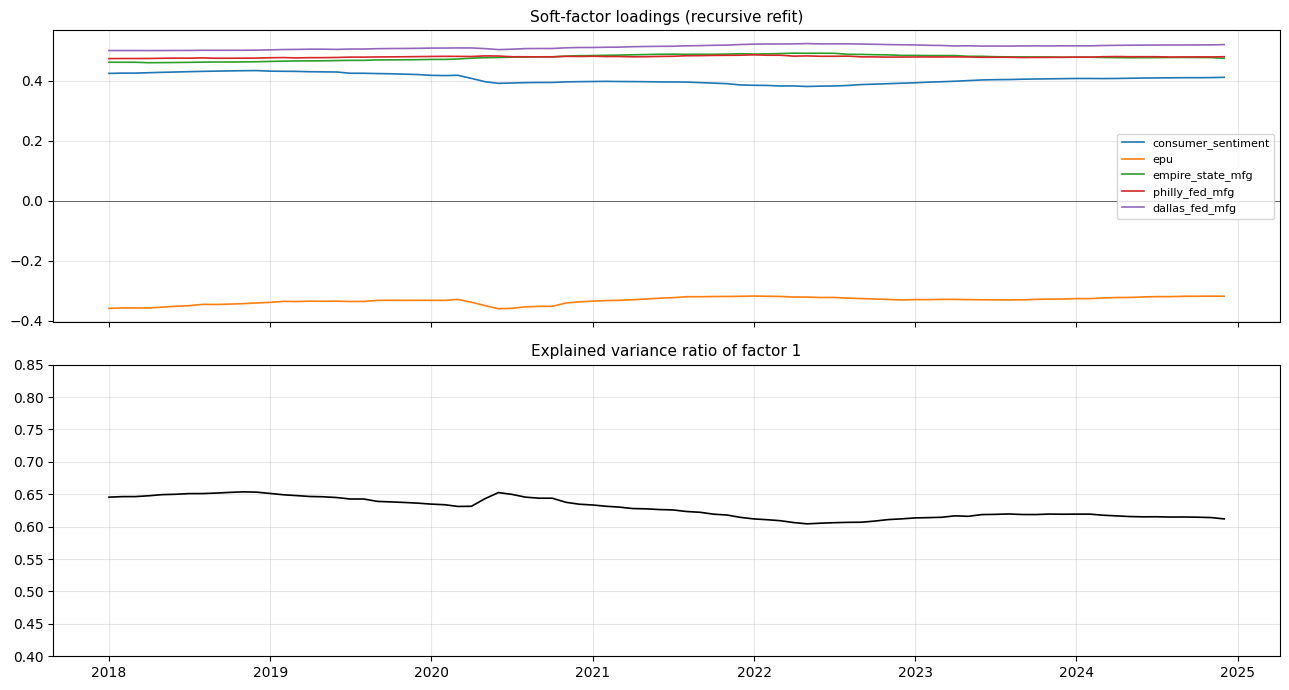

Loading mean/std across refits:
      consumer_sentiment    epu  empire_state_mfg  philly_fed_mfg  dallas_fed_mfg
mean               0.407 -0.333             0.478           0.480           0.513
std                0.016  0.012             0.010           0.003           0.007

Explained var ratio: mean 0.629, range [0.604, 0.654]


In [2]:
loadings, evr = [], []
for origin in ORIGINS:
    raw = build_feature_frame(cfg, cubes, static, origin, variables=SOFT)
    try:
        sf = SoftFactor(SOFT, n_components=1, sign_reference='consumer_sentiment').fit(raw)
        loadings.append(sf.loadings_['f1'].rename(origin))
        evr.append((origin, sf.explained_variance_ratio_[0]))
    except ValueError:
        continue
L = pd.DataFrame(loadings); evr = pd.Series(dict(evr))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for col in L.columns:
    axes[0].plot(L.index, L[col], lw=1.2, label=col)
axes[0].axhline(0, color='black', lw=0.4)
axes[0].set_title('Soft-factor loadings (recursive refit)', fontsize=11)
axes[0].legend(fontsize=8, loc='best'); axes[0].grid(alpha=0.3)
axes[1].plot(evr.index, evr.values, color='black', lw=1.2)
axes[1].set_title('Explained variance ratio of factor 1', fontsize=11)
axes[1].set_ylim(0.4, 0.85); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Loading mean/std across refits:')
print(L.agg(['mean','std']).round(3).to_string())
print(f"\nExplained var ratio: mean {evr.mean():.3f}, range [{evr.min():.3f}, {evr.max():.3f}]")

## 2. Factor history (full-sample loadings)

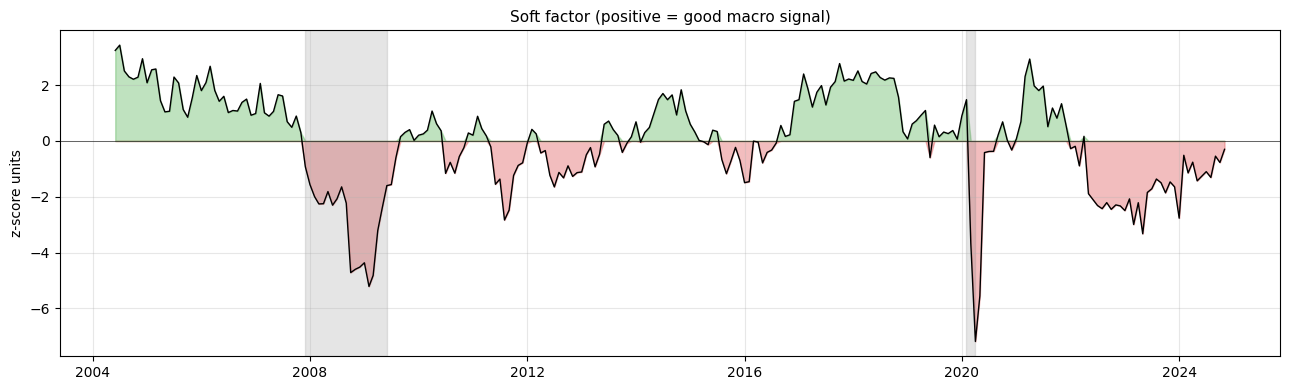

In [3]:
ff = build_feature_frame(cfg, cubes, static, pd.Timestamp('2024-12-01'), variables=SOFT)
sf = SoftFactor(SOFT, n_components=1, sign_reference='consumer_sentiment').fit(ff)
scores = sf.transform(ff).dropna()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(scores.index, scores['soft_f1'].clip(upper=0), 0, color='#d62728', alpha=0.3)
ax.fill_between(scores.index, scores['soft_f1'].clip(lower=0), 0, color='#2ca02c', alpha=0.3)
ax.plot(scores.index, scores['soft_f1'], color='black', lw=1.0)
for s_, e_ in BANDS:
    ax.axvspan(s_, e_, color='grey', alpha=0.2)
ax.axhline(0, color='black', lw=0.4)
ax.set_title('Soft factor (positive = good macro signal)', fontsize=11)
ax.set_ylabel('z-score units'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Short-window horse race (COVID-dummy model)

In [4]:
res = pd.read_parquet(ROOT / 'data/forecasts/short_window_covid_dummy.parquet')

def rmse(spec):
    s = res[res.spec==spec].dropna(subset=['error']).copy(); s['se']=s['error']**2
    return s.groupby(['target','horizon'])['se'].mean().pow(0.5)

tab = pd.DataFrame({'hard': rmse('hard_only'),
                    'hard_UM': rmse('hard_plus_umcsent'),
                    'hard_fac': rmse('hard_plus_soft_factor')})
tab['UM_imp_%']  = 100*(tab['hard']-tab['hard_UM'])/tab['hard']
tab['fac_imp_%'] = 100*(tab['hard']-tab['hard_fac'])/tab['hard']
print(tab.round(3).to_string())

                                 hard  hard_UM  hard_fac  UM_imp_%  fac_imp_%
target                horizon                                                
core_pce              1         0.455    0.464     0.419    -2.019      7.999
                      3         0.849    0.840     0.795     1.014      6.390
                      6         1.185    1.161     1.192     2.018     -0.650
                      12        1.706    1.941     1.723   -13.803     -1.011
industrial_production 1         4.349    3.839     4.505    11.727     -3.579
                      3         9.299    8.303     7.187    10.712     22.711
                      6        11.651   11.324     7.578     2.812     34.958
                      12       12.346   16.978     6.399   -37.515     48.170
payrolls              1         2.641    2.586     2.500     2.103      5.371
                      3         4.735    4.949     4.108    -4.528     13.234
                      6         6.519    7.793     4.685   -19.5

The soft **factor** delivers large gains for real-activity targets at
longer horizons — unemployment +34% (h=6) and +57% (h=12), industrial
production +35% / +48%, payrolls +28% / +47%. UMCSENT alone does not
(it often hurts at long horizons), which is the case for aggregating
multiple soft indicators rather than relying on a single survey.

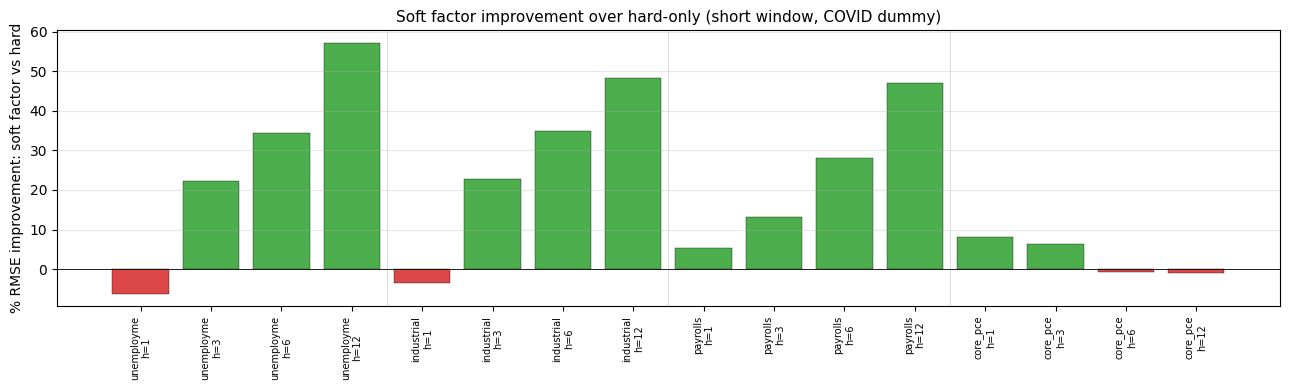

In [5]:
# Bar chart of factor improvement vs hard-only, by target and horizon
targets = ['unemployment','industrial_production','payrolls','core_pce']
horizons = [1,3,6,12]
x = np.arange(len(targets)*len(horizons))
labels = [f'{t[:10]}\nh={h}' for t in targets for h in horizons]
vals = [tab.loc[(t,h),'fac_imp_%'] for t in targets for h in horizons]
colors = ['#2ca02c' if v>=0 else '#d62728' for v in vals]

fig, ax = plt.subplots(figsize=(13,4))
ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.3)
ax.axhline(0, color='black', lw=0.6)
for i in range(1,len(targets)):
    ax.axvline(i*len(horizons)-0.5, color='grey', lw=0.4, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7, rotation=90)
ax.set_ylabel('% RMSE improvement: soft factor vs hard')
ax.set_title('Soft factor improvement over hard-only (short window, COVID dummy)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Giacomini–White test (short window)

In [6]:
def gw_panel(soft_spec):
    rows = []
    for tgt in targets:
        for h in horizons:
            hard = res[(res.target==tgt)&(res.horizon==h)&(res.spec=='hard_only')].set_index('origin')
            soft = res[(res.target==tgt)&(res.horizon==h)&(res.spec==soft_spec)].set_index('origin')
            idx = hard.index.intersection(soft.index)
            l1=(hard.loc[idx,'error']**2); l2=(soft.loc[idx,'error']**2); vx=vix_m.reindex(idx)
            ok = l1.notna()&l2.notna()&vx.notna()
            l1,l2,vx = l1[ok].values,l2[ok].values,vx[ok].values
            if len(l1)<20: continue
            u=gw_test(l1,l2,tau=h,choice='uncond'); c=gw_test(l1,l2,tau=h,choice='cond',instruments=vx)
            rows.append({'target':tgt,'horizon':h,'n':len(l1),
                         'soft_imp_%':100*(np.sqrt(l1.mean())-np.sqrt(l2.mean()))/np.sqrt(l1.mean()),
                         'DM_p':u.pval,'GW_vix_p':c.pval,
                         'better':'soft' if u.better_model==2 else 'hard'})
    return pd.DataFrame(rows)

print('=== hard vs hard + soft factor ===')
print(gw_panel('hard_plus_soft_factor').round(4).to_string(index=False))

=== hard vs hard + soft factor ===
               target  horizon  n  soft_imp_%   DM_p  GW_vix_p better
         unemployment        1 84     -6.2000 0.6769    0.8031   hard
         unemployment        3 84     22.1886 0.2591    0.3522   soft
         unemployment        6 84     34.4667 0.2500    0.3561   soft
         unemployment       12 83     57.1736 0.2595    0.3737   soft
industrial_production        1 84     -3.5795 0.5805    0.2125   hard
industrial_production        3 84     22.7114 0.1662    0.3835   soft
industrial_production        6 84     34.9579 0.1686    0.3747   soft
industrial_production       12 84     48.1695 0.2009    0.4134   soft
             payrolls        1 84      5.3714 0.3240    0.5587   soft
             payrolls        3 84     13.2344 0.1912    0.3308   soft
             payrolls        6 84     28.1281 0.1853    0.3600   soft
             payrolls       12 84     47.0190 0.2020    0.3936   soft
             core_pce        1 84      7.9988 0.3841   

## Takeaways

1. **The factor is stable** — loadings barely move across 84 recursive refits; explained variance ~0.60–0.65 throughout.
2. **Large RMSE gains at longer horizons** for real-activity targets from the multi-indicator soft factor; inflation is roughly unchanged.
3. **GW p-values are suggestive but not significant** — the best DM p-values sit around 0.17–0.26 with only n=84 origins. The sign of the effect is consistently "soft", but the short window lacks the power to reject equal predictive ability at conventional levels.

The pattern — large point gains, low power, effect concentrated in real activity at longer horizons — is exactly what motivates the regime-switching models in M4, which pool information more efficiently than the blunt VIX-instrument GW test on a short sample.